# AI-Based Flood Prediction & Early Warning System (Pakistan)

This project develops a machine learning-based system to predict flood risk using geospatial and meteorological data and provides early warning alerts.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

import folium

In [36]:
df = pd.read_csv('D:/ML Model/Dataset/test1.csv')


In [37]:
df.head()


,year,province,district,flood_event,deaths,houses_destroyed,houses_damaged,people_affected,cropland_acres,severity,flood_type,source,latitude,longitude
0,2010,KPK,Nowshera,2010 Super Flood,120,45000,60000,850000,300000,Catastrophic,Riverine,World Bank PDNA 2010; PMC,34.0150,71.9844
1,2010,KPK,Charsadda,2010 Super Flood,95,38000,50000,720000,250000,Catastrophic,Riverine,World Bank PDNA 2010,34.1482,71.7307
2,2010,KPK,Swat,2010 Super Flood,210,60000,75000,1100000,400000,Catastrophic,Flash Flood,World Bank PDNA 2010; PMC,35.2227,72.4258
3,2010,Punjab,Muzaffargarh,2010 Super Flood,45,28000,40000,600000,500000,Severe,Riverine,World Bank PDNA 2010,30.0704,71.1930
4,2010,Punjab,Rajanpur,2010 Super Flood,38,22000,35000,520000,420000,Severe,Riverine,World Bank PDNA 2010,29.1044,70.3297


In [38]:
print(df.shape)

(30, 14)


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   province          30 non-null     str    
 2   district          30 non-null     str    
 3   flood_event       30 non-null     str    
 4   deaths            30 non-null     int64  
 5   houses_destroyed  30 non-null     int64  
 6   houses_damaged    30 non-null     int64  
 7   people_affected   30 non-null     int64  
 8   cropland_acres    30 non-null     int64  
 9   severity          30 non-null     str    
 10  flood_type        30 non-null     str    
 11  source            30 non-null     str    
 12  latitude          30 non-null     float64
 13  longitude         30 non-null     float64
dtypes: float64(2), int64(6), str(6)
memory usage: 3.4 KB


In [49]:
# Remove duplicates
df = df.drop_duplicates()

In [50]:
# Numeric columns
numeric_cols = [
    "deaths",
    "houses_destroyed",
    "houses_damaged",
    "people_affected",
    "cropland_acres",
    "latitude",
    "longitude"
]

In [51]:
# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [52]:
# Drop missing
df = df.dropna(subset=numeric_cols)

In [53]:
# Feature engineering
df["damage"] = df["houses_destroyed"] + df["houses_damaged"]

In [ ]:
# Clean categorical
categorical_cols = ["province", "district", "flood_event", "severity", "flood_type"]

for col in categorical_cols:
    df[col] = df[col].str.strip()

In [56]:
# Encode categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [57]:
# Final check
print(df.isnull().sum())   # should be 0
print(df.dtypes)           # numeric + encoded ints
print(df.shape)

year                0
province            0
district            0
flood_event         0
deaths              0
houses_destroyed    0
houses_damaged      0
people_affected     0
cropland_acres      0
severity            0
flood_type          0
source              0
latitude            0
longitude           0
damage              0
dtype: int64
year                  int64
province              int64
district              int64
flood_event           int64
deaths                int64
houses_destroyed      int64
houses_damaged        int64
people_affected       int64
cropland_acres        int64
severity              int64
flood_type            int64
source                  str
latitude            float64
longitude           float64
damage                int64
dtype: object
(30, 15)


In [74]:
# Create damage
df["damage"] = df["houses_destroyed"] + df["houses_damaged"]

# Create balanced flood risk using damage distribution
df["flood_risk"] = pd.qcut(
    df["damage"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["target"] = le.fit_transform(df["flood_risk"])

# Check result
print(df["flood_risk"].value_counts())
print(df[["damage", "flood_risk", "target"]].head())

flood_risk
Low       10
Medium    10
High      10
Name: count, dtype: int64
   damage flood_risk  target
0  105000       High       0
1   88000     Medium       2
2  135000       High       0
3   68000     Medium       2
4   57000     Medium       2


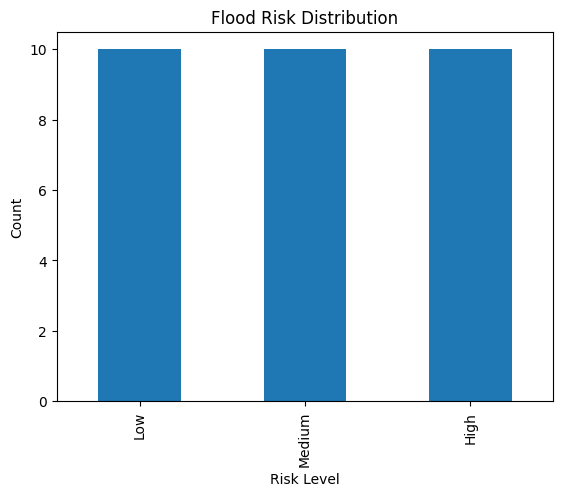

<Figure size 800x500 with 0 Axes>

In [75]:
import matplotlib.pyplot as plt

df["flood_risk"].value_counts().plot(
    kind="bar",
    title="Flood Risk Distribution"
)
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.figure(figsize=(8,5))
plt.show()

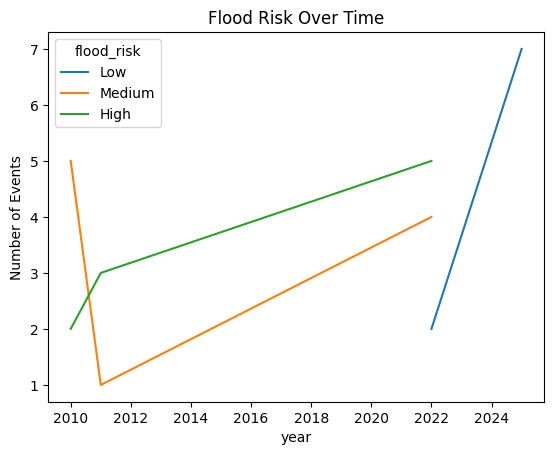

<Figure size 800x500 with 0 Axes>

In [76]:
df.groupby(["year", "flood_risk"]).size().unstack().plot(
    kind="line",
    title="Flood Risk Over Time"
)

plt.ylabel("Number of Events")
plt.figure(figsize=(8,5))
plt.show()

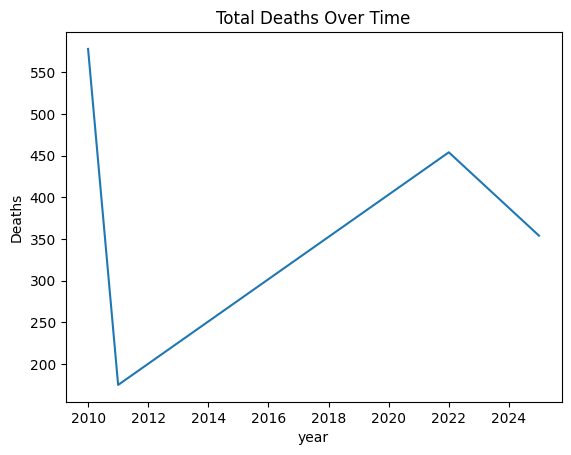

<Figure size 800x500 with 0 Axes>

In [77]:
df.groupby("year")["deaths"].sum().plot(
    kind="line",
    title="Total Deaths Over Time"
)
plt.ylabel("Deaths")
plt.figure(figsize=(8,5))
plt.show()

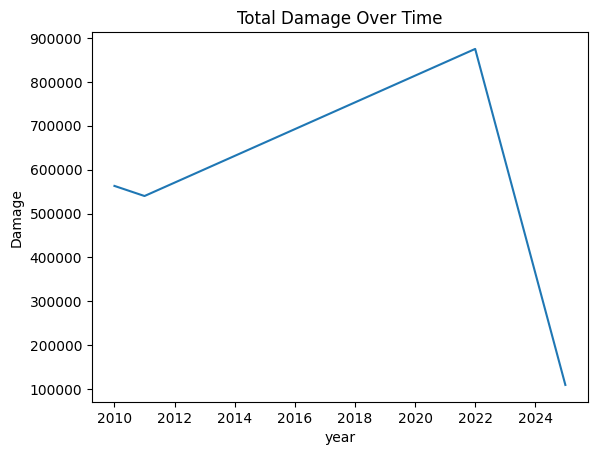

<Figure size 800x500 with 0 Axes>

In [78]:
df.groupby("year")["damage"].sum().plot(
    kind="line",
    title="Total Damage Over Time"
)
plt.ylabel("Damage")
plt.figure(figsize=(8,5))
plt.show()

In [79]:
#Feature Selection:
features = [
    "latitude",
    "longitude",
    "year",
    "deaths",
    "houses_destroyed",
    "houses_damaged",
    "people_affected",
    "cropland_acres",
    "damage"
]

X = df[features]
y = df["flood_risk"]

In [80]:
#train test split
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df[[
    "latitude",
    "longitude",
    "year",
    "people_affected",
    "cropland_acres"
]]

y = df["flood_risk"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24, 5)
X_test: (6, 5)
y_train: (24,)
y_test: (6,)


In [81]:
#verify class distribution:
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
flood_risk
Low       0.333333
Medium    0.333333
High      0.333333
Name: proportion, dtype: float64

Test distribution:
flood_risk
Low       0.333333
Medium    0.333333
High      0.333333
Name: proportion, dtype: float64


In [83]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Logistic Regression
Accuracy: 0.5
              precision    recall  f1-score   support

        High       0.50      0.50      0.50         2
         Low       1.00      0.50      0.67         2
      Medium       0.33      0.50      0.40         2

    accuracy                           0.50         6
   macro avg       0.61      0.50      0.52         6
weighted avg       0.61      0.50      0.52         6


Random Forest
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

        High       0.67      1.00      0.80         2
         Low       1.00      1.00      1.00         2
      Medium       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6


Gradient Boosting
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

        High       0.50      0.50      0.50         2
  

In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.33333333 0.66666667 1.         0.83333333 0.66666667]
Mean Accuracy: 0.7


In [85]:
model.fit(X_train, y_train)

import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

people_affected    0.320401
cropland_acres     0.258625
year               0.194168
longitude          0.116826
latitude           0.109979
dtype: float64


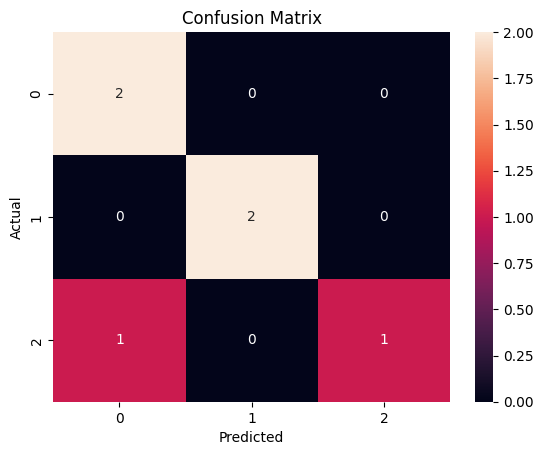

In [86]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, model.predict(X_test))

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [87]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

In [88]:
X = df[["people_affected", "cropland_acres", "year"]]

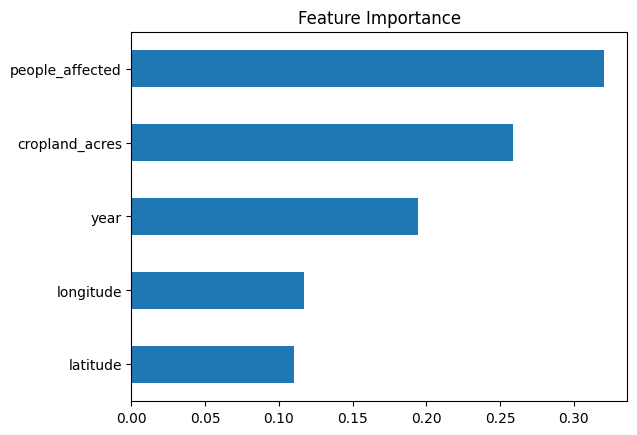

In [89]:
importance.sort_values().plot(kind="barh", title="Feature Importance")
import matplotlib.pyplot as plt
plt.show()

In [92]:
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [93]:
from sklearn.metrics import accuracy_score, classification_report

preds = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

        High       0.67      1.00      0.80         2
         Low       1.00      1.00      1.00         2
      Medium       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



In [94]:
def predict_flood(lat, lon, year, people, cropland):
    data = pd.DataFrame([{
        "latitude": lat,
        "longitude": lon,
        "year": year,
        "people_affected": people,
        "cropland_acres": cropland
    }])
    
    return best_model.predict(data)[0]

In [95]:
result = predict_flood(
    lat=33.7,
    lon=73.0,
    year=2024,
    people=5000,
    cropland=200
)

print("Flood Risk:", result)

Flood Risk: Low


In [96]:
def predict_flood(lat, lon, year, people, cropland):
    data = pd.DataFrame([{
        "latitude": lat,
        "longitude": lon,
        "year": year,
        "people_affected": people,
        "cropland_acres": cropland
    }])
    
    pred = best_model.predict(data)[0]
    return le.inverse_transform([pred])[0]

In [97]:
def generate_alert(risk):
    risk = str(risk).strip().capitalize()
    
    alerts = {
        "High": "🚨 RED ALERT: Emergency",
        "Medium": "⚠️ YELLOW ALERT: Warning",
        "Low": "✅ GREEN: Safe"
    }
    
    return alerts.get(risk, "❓ Unknown Risk Level")

In [100]:
def predict_and_alert(lat, lon, year, people, cropland):
    data = pd.DataFrame([{
        "latitude": lat,
        "longitude": lon,
        "year": year,
        "people_affected": people,
        "cropland_acres": cropland
    }])
    
    risk = best_model.predict(data)[0]   # already gives Low/Medium/High
    alert = generate_alert(risk)
    
    return risk, alert

In [101]:
risk, alert = predict_and_alert(
    lat=33.7,
    lon=73.0,
    year=2024,
    people=5000,
    cropland=200
)

print("Predicted Risk:", risk)
print("Alert:", alert)

Predicted Risk: Low
Alert: ✅ GREEN: Safe


In [105]:
import folium

m = folium.Map(location=[30.3753, 69.3451], zoom_start=5)

color_map = {"Low": "green", "Medium": "orange", "High": "red"}

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=color_map[row["flood_risk"]],
        fill=True,
        fill_color=color_map[row["flood_risk"]],
        fill_opacity=0.7,
        tooltip=f"{row['district']} ({row['province']})",
        popup=(
            f"<b>Risk:</b> {row['flood_risk']}<br>"
            f"<b>Deaths:</b> {row['deaths']}<br>"
            f"<b>People Affected:</b> {row['people_affected']}<br>"
            f"<b>Year:</b> {row['year']}"
        )
    ).add_to(m)

legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 150px; height: 120px; 
     background-color: white; z-index:9999; font-size:14px;
     border:2px solid grey; padding: 10px;">
<b>Flood Risk</b><br>
<i style="color:green;">●</i> Low<br>
<i style="color:orange;">●</i> Medium<br>
<i style="color:red;">●</i> High
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

In [106]:
m.save("flood_risk_map.html")

## Conclusion

- Developed ML model for flood risk prediction  
- Used geospatial and meteorological features  
- Built early warning system  
- Visualized high-risk regions using maps  

This system can support disaster management and decision-making.

In [107]:
df[["latitude", "longitude", "flood_risk", "year"]].to_json(
    "flood_data.json",
    orient="records"
)